In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore

# 1.Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)

In [2]:
# reading the Vehicle dataset
df=pd.read_csv("vehicle.csv")

In [9]:
# Checking if missing values are present
df.isnull().sum(axis=1).head(20)

0     0
1     0
2     0
3     0
4     0
5     1
6     0
7     0
8     0
9     1
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    1
dtype: int64

In [11]:
# We can see that there are some missing values in the dataset. Handling this missing data
new_df=df.dropna()

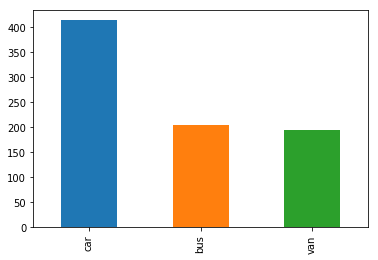

In [12]:
new_df['class'].value_counts()
new_df['class'].value_counts().plot(kind='bar')

In [13]:
# check if the new dataset contains missing values
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 813 entries, 0 to 845
Data columns (total 19 columns):
compactness                    813 non-null int64
circularity                    813 non-null float64
distance_circularity           813 non-null float64
radius_ratio                   813 non-null float64
pr.axis_aspect_ratio           813 non-null float64
max.length_aspect_ratio        813 non-null int64
scatter_ratio                  813 non-null float64
elongatedness                  813 non-null float64
pr.axis_rectangularity         813 non-null float64
max.length_rectangularity      813 non-null int64
scaled_variance                813 non-null float64
scaled_variance.1              813 non-null float64
scaled_radius_of_gyration      813 non-null float64
scaled_radius_of_gyration.1    813 non-null float64
skewness_about                 813 non-null float64
skewness_about.1               813 non-null float64
skewness_about.2               813 non-null float64
hollows_ratio    

In [14]:
# Standardize data usong z-score
numeric_cols = new_df.drop('class', axis=1)

Prob_type  = new_df.pop("class")

numeric_cols = numeric_cols.apply(zscore)

new_df = numeric_cols.join(Prob_type)   # Recreating mpg_df by combining numerical columns with car names

new_df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,0.163231,0.520408,0.060669,0.264970,1.283254,0.299721,-0.198517,0.129648,-0.217151,0.766312,-0.397397,-0.339014,0.301676,-0.321192,-0.071523,0.371287,-0.321809,0.171837,van
1,-0.322874,-0.619123,0.124067,-0.836393,-0.599253,0.085785,-0.591720,0.514333,-0.606014,-0.337462,-0.590034,-0.618754,-0.502972,-0.053505,0.538425,0.147109,0.003400,0.442318,van
2,1.256966,0.845988,1.518823,1.187734,0.530251,0.299721,1.162569,-1.152637,0.949438,0.697326,1.111591,1.122486,1.415804,0.080339,1.555006,-0.413338,-0.159204,0.036596,car
3,-0.079822,-0.619123,-0.002729,-0.300595,0.153750,0.085785,-0.742952,0.642562,-0.606014,-0.337462,-0.911095,-0.738643,-1.462359,-1.258099,-0.071523,-0.301249,1.629444,1.524243,van
4,-1.052030,-0.130753,-0.763506,1.068668,5.173770,9.285029,-0.591720,0.514333,-0.606014,-0.268476,1.689501,-0.647299,0.425468,7.307905,0.538425,-0.189159,-1.460039,-1.721531,bus


In [15]:
# Since the dimensions of the data are not really known to us, it would be wise to standardize the data using z scores before we go for any clustering methods.
# This can be achieved using z-score.

In [18]:
new_df.describe()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
count,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02,8.130000e+02
mean,-2.425284e-16,-4.642999e-16,-2.351542e-16,3.665238e-16,-2.047016e-16,-1.349201e-16,3.714399e-16,-2.062038e-16,-2.651972e-16,-7.398756e-16,-3.031605e-17,-3.550529e-17,3.348422e-16,1.312159e-16,-1.693329e-17,9.845889e-17,-1.169490e-15,3.482249e-16
std,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00,1.000616e+00
min,-2.510344e+00,-1.921444e+00,-2.665447e+00,-1.937757e+00,-1.854258e+00,-1.411767e+00,-1.710835e+00,-1.922008e+00,-1.383740e+00,-2.062109e+00,-1.874279e+00,-1.452266e+00,-2.019423e+00,-1.793474e+00,-1.291420e+00,-1.422141e+00,-2.110457e+00,-1.992013e+00
25%,-8.089782e-01,-7.819133e-01,-7.635057e-01,-8.363933e-01,-5.992534e-01,-3.420870e-01,-6.824590e-01,-1.024408e+00,-6.060138e-01,-7.513773e-01,-6.863524e-01,-6.872619e-01,-7.815035e-01,-7.227236e-01,-8.847879e-01,-7.496057e-01,-8.096219e-01,-6.396066e-01
50%,-7.982157e-02,-1.307527e-01,-1.929234e-01,-6.246222e-02,-9.725132e-02,-1.281510e-01,-3.497491e-01,2.578765e-01,-2.171510e-01,-1.305046e-01,-3.010789e-01,-4.246486e-01,-3.875161e-02,-1.873484e-01,-7.152328e-02,-1.891593e-01,3.400092e-03,1.718371e-01
75%,7.708611e-01,6.831980e-01,1.011639e+00,7.710020e-01,4.047507e-01,2.997208e-01,8.903515e-01,6.425619e-01,9.494376e-01,7.663115e-01,9.189540e-01,8.427456e-01,7.349483e-01,3.480268e-01,5.384252e-01,7.075550e-01,6.538177e-01,7.127995e-01
max,3.079857e+00,2.311100e+00,1.899212e+00,4.878790e+00,9.566288e+00,9.926837e+00,2.916857e+00,2.565989e+00,3.282615e+00,2.766901e+00,4.225885e+00,3.309026e+00,2.901308e+00,8.378655e+00,3.181535e+00,3.173519e+00,2.767675e+00,2.065206e+00


In [20]:
new_df.shape

(813, 19)

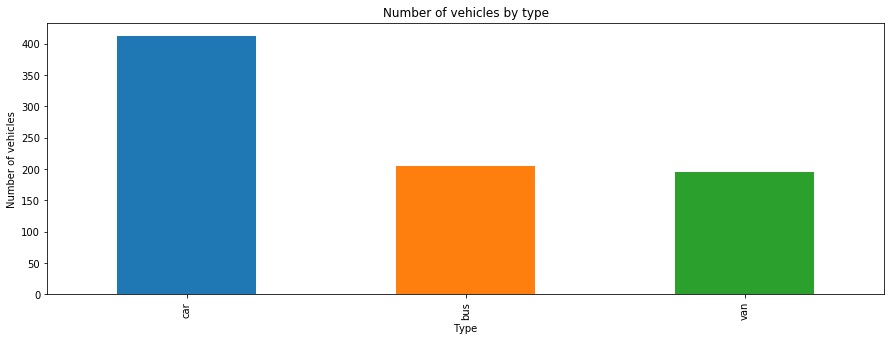

In [23]:
new_df['class'].value_counts().nlargest(10).plot(kind='bar', figsize=(15,5))
plt.title("Number of vehicles by type")
plt.ylabel('Number of vehicles')
plt.xlabel('Type');

# 2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)

C:\Anaconda\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\Anaconda\lib\site-packages\statsmodels\nonparametric\kde.py:448: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
C:\Anaconda\lib\site-packages\statsmodels\nonparametric\kde.py:448: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.


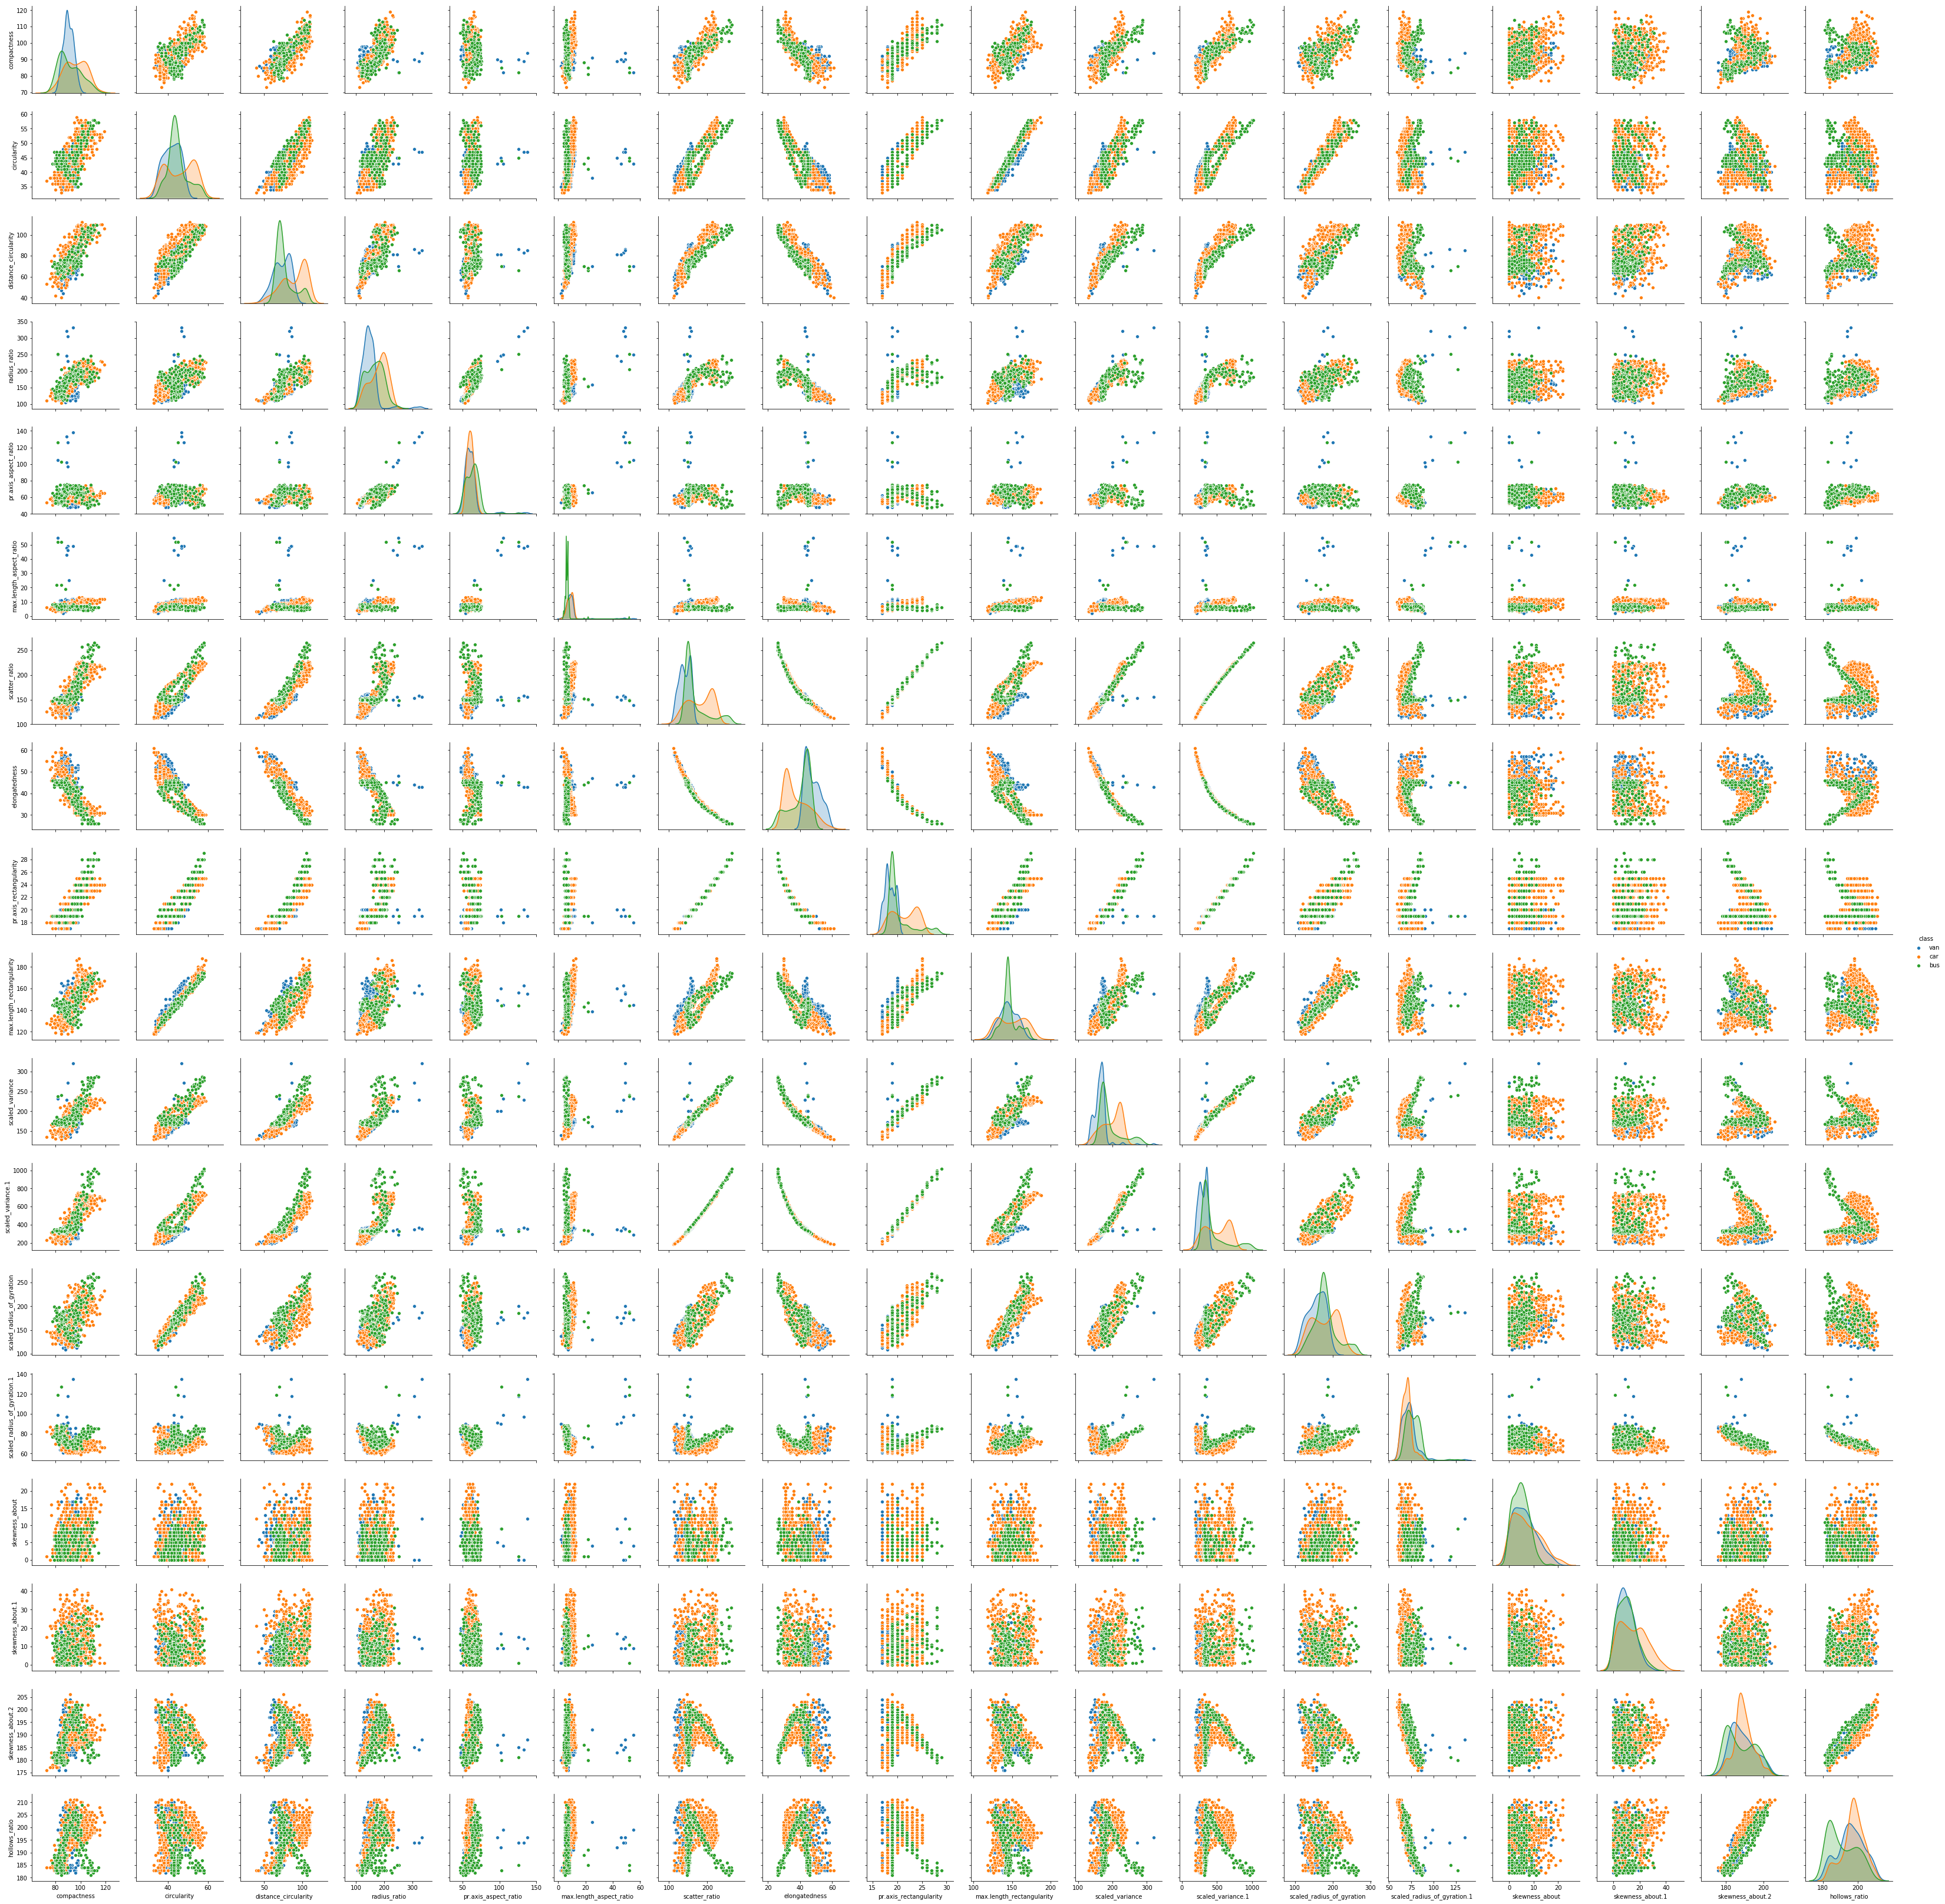

In [16]:
sns.pairplot(df, diag_kind='kde', hue = 'class')

In [17]:
new_df.corr()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
compactness,1.000000,0.689885,0.789955,0.688130,0.090557,0.150369,0.814026,-0.788051,0.814227,0.674902,0.764386,0.820240,0.581405,-0.258437,0.231648,0.168384,0.296195,0.372806
circularity,0.689885,1.000000,0.797704,0.623950,0.155023,0.251619,0.858149,-0.825108,0.856137,0.965366,0.806108,0.850932,0.935594,0.049070,0.141726,-0.001975,-0.113902,0.049331
distance_circularity,0.789955,0.797704,1.000000,0.771404,0.163386,0.265591,0.909023,-0.912713,0.897261,0.773459,0.865683,0.891789,0.705689,-0.238145,0.110280,0.277851,0.145258,0.343228
radius_ratio,0.688130,0.623950,0.771404,1.000000,0.667375,0.452460,0.743470,-0.795761,0.716210,0.570478,0.806788,0.731773,0.544636,-0.175348,0.044693,0.178079,0.375591,0.470895
pr.axis_aspect_ratio,0.090557,0.155023,0.163386,0.667375,1.000000,0.652093,0.113696,-0.191193,0.086992,0.133553,0.290375,0.100668,0.135663,0.173060,-0.059244,-0.040769,0.229702,0.257566
max.length_aspect_ratio,0.150369,0.251619,0.265591,0.452460,0.652093,1.000000,0.171445,-0.183242,0.167514,0.309180,0.331124,0.150069,0.197179,0.308329,0.016461,0.041210,-0.030543,0.139283
scatter_ratio,0.814026,0.858149,0.909023,0.743470,0.113696,0.171445,1.000000,-0.973413,0.991992,0.808154,0.950067,0.996396,0.795748,-0.045632,0.070118,0.227375,0.009967,0.138424
elongatedness,-0.788051,-0.825108,-0.912713,-0.795761,-0.191193,-0.183242,-0.973413,1.000000,-0.950345,-0.771099,-0.937846,-0.956858,-0.761563,0.119750,-0.046621,-0.201325,-0.117568,-0.233408
pr.axis_rectangularity,0.814227,0.856137,0.897261,0.716210,0.086992,0.167514,0.991992,-0.950345,1.000000,0.811979,0.935653,0.992119,0.792895,-0.033769,0.078701,0.231171,-0.017383,0.117202
max.length_rectangularity,0.674902,0.965366,0.773459,0.570478,0.133553,0.309180,0.808154,-0.771099,0.811979,1.000000,0.744760,0.796230,0.865240,0.031098,0.130356,0.013045,-0.108019,0.086792


# 3. Use PCA from scikit learn and elbow plot to find out reduced number of dimension (which covers more than 95% of the variance) - 10 points

In [25]:
X =  new_df.drop("class", axis=1)
y =  new_df.pop("class")

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5 , random_state=0)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)

In [27]:
cov_matrix = np.cov(X_train_std.T)

print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00246914  0.71857299  0.81968174  0.7184382   0.10222867  0.16247929
   0.83168261 -0.81252913  0.83063783  0.70324794  0.78441495  0.83641711
   0.60191808 -0.24267391  0.208847    0.15813353  0.27012749  0.35919554]
 [ 0.71857299  1.00246914  0.81476025  0.65447539  0.17004257  0.26372523
   0.86563516 -0.83611966  0.86290737  0.97145445  0.81679465  0.85895845
   0.93840274  0.07152012  0.13562099  0.01675663 -0.13550788  0.03526237]
 [ 0.81968174  0.81476025  1.00246914  0.79297826  0.17159267  0.26629393
   0.91543963 -0.91574307  0.90217286  0.78485411  0.87824936  0.9015062
   0.71746093 -0.18939616  0.10729693  0.27601214  0.09305932  0.29558338]
 [ 0.7184382   0.65447539  0.79297826  1.00246914  0.65433913  0.39882048
   0.76423025 -0.81097281  0.73498908  0.58527194  0.81136144  0.75683439
   0.58235073 -0.18001749  0.04543146  0.19024688  0.33938088  0.44665775]
 [ 0.10222867  0.17004257  0.17159267  0.65433913  1.00246914  0.56993819
   0.12513415

In [28]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[ 2.77469297e-01  1.38620885e-01 -1.29462888e-01  5.09178339e-02
   4.50372303e-02 -8.47827119e-03 -4.07105623e-01 -4.45341468e-01
  -6.30117777e-01 -2.86651518e-01  2.02222672e-02  7.20884760e-02
   1.68503227e-01 -2.39233403e-03  3.93240116e-03  3.17604199e-02
   6.00627102e-02 -2.05805147e-02]
 [ 2.95952800e-01 -1.06445591e-01 -2.71110433e-02  2.03629035e-01
  -7.13326920e-02  2.22445767e-01  2.95624192e-01 -1.43764262e-01
  -1.82145019e-02  8.21376337e-02 -2.00433066e-03 -1.71824937e-01
  -2.26180079e-03  3.37045420e-02  2.17853549e-01  6.49823868e-01
  -1.30268705e-01  4.14488509e-01]
 [ 3.03917306e-01  7.05443004e-02 -6.02794594e-02 -7.26698113e-02
   4.17895738e-02  1.25744379e-01 -2.53244029e-02  4.63739904e-01
  -7.95484999e-02 -2.43438159e-01  7.00905056e-01  1.86555553e-03
  -2.45175301e-01 -1.07404625e-02 -3.68050969e-02 -4.63386724e-02
   1.44917512e-01  1.37471738e-01]
 [ 2.70656177e-01  1.91533218e-01  2.54581483e-01 -6.11279604e-02
  -6.52323882e-02 -

In [29]:
print("Eigen Values:")
pd.DataFrame(eig_vals).transpose()

Eigen Values:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,9.543443,3.016202,1.775859,1.217214,0.915611,0.540143,0.396093,0.205972,0.150085,0.091336,0.059318,0.043633,0.035937,0.000312,0.006197,0.011961,0.019179,0.015951


In [30]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 52.88853895  69.60394147  79.4455227   86.19116614  91.26536303
  94.25876543  96.45386413  97.59533545  98.42708467  98.93325703
  99.26199073  99.50379876  99.70295913  99.80924468  99.89764321
  99.96392837  99.99827131 100.        ]


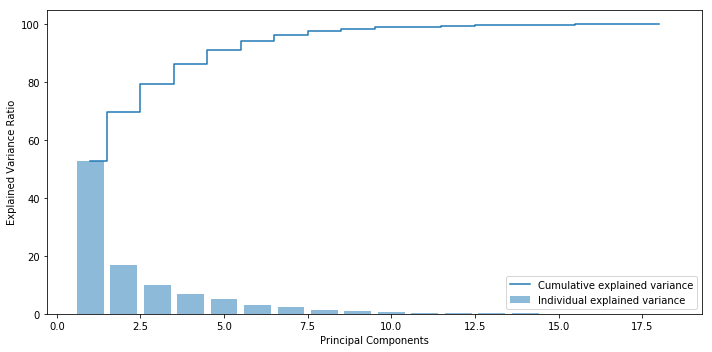

In [31]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [32]:
# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eig_vals[index], eig_vecs[:,index]) for index in range(len(eig_vals))]


# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()
eig_pairs.reverse()

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sort = [eig_pairs[index][0] for index in range(len(eig_vals))]
eigvectors_sort = [eig_pairs[index][1] for index in range(len(eig_vals))]



P_reduce = np.array(eigvectors_sort[0:10]).transpose()   # Selecting first 8 eigen vectors of all 18 since they cover about 95% of the variance

Proj_train_data = np.dot(X_train_std,P_reduce)   # projecting training data onto the eight eigen vectors

Proj_test_data = np.dot(X_test_std,P_reduce)    # projecting test data onto the eight eigen vectors

In [33]:
# complete matrix operation 
print(y_train.shape)
X_train_std.shape, P_reduce.shape, Proj_train_data.shape

(406,)


((406, 18), (18, 10), (406, 10))

In [34]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(Proj_train_data, y_train)
result = model.score(Proj_test_data, y_test)
print(result)

C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Anaconda\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


0.8746928746928747


In [36]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(Proj_train_data, y_train)
result = model.score(Proj_test_data, y_test)
print(result)

0.85995085995086


C:\Anaconda\lib\site-packages\sklearn\ensemble\forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


In [37]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(Proj_train_data, y_train)
result = model.score(Proj_test_data, y_test)
print(result)

0.8108108108108109


# 4. Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)

## Building SVM using kernel=linear

In [39]:
from sklearn.svm import SVC

# Building a Support Vector Machine on train data
svc_model = SVC(C= .01, kernel='linear', gamma= 1)
svc_model.fit(X_train, y_train)

prediction = svc_model.predict(X_test)

In [40]:
# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.8251231527093597
0.8402948402948403


In [41]:
# Building a Support Vector Machine on train data
svc_model = SVC(C= .05, kernel='linear', gamma= 1)
svc_model.fit(X_train, y_train)

prediction = svc_model.predict(X_test)

In [42]:
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.9137931034482759
0.9066339066339066


In [43]:
# Building a Support Vector Machine on train data
svc_model = SVC(C= .5, kernel='linear', gamma= 1)
svc_model.fit(X_train, y_train)

prediction = svc_model.predict(X_test)

In [44]:
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.9458128078817734
0.9606879606879607


In [45]:
# Building a Support Vector Machine on train data
svc_model = SVC(C=1, kernel='linear', gamma= 1)
svc_model.fit(X_train, y_train)

prediction = svc_model.predict(X_test)

In [46]:
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.9605911330049262
0.9705159705159705


## Building SVM using kernel=rbf

In [48]:
# Building a Support Vector Machine on train data
svc_model = SVC(C= .01, kernel='rbf', gamma= 1)
svc_model.fit(X_train, y_train)

prediction = svc_model.predict(X_test)

# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.5197044334975369
0.4963144963144963


In [49]:
# Building a Support Vector Machine on train data
svc_model = SVC(C= .05, kernel='rbf', gamma= 1)
svc_model.fit(X_train, y_train)

prediction = svc_model.predict(X_test)

# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.5197044334975369
0.4963144963144963


In [51]:
# Building a Support Vector Machine on train data
svc_model = SVC(C= .5, kernel='rbf', gamma= 1)
svc_model.fit(X_train, y_train)

prediction = svc_model.predict(X_test)

# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

0.8300492610837439
0.6167076167076168


In [52]:
# Building a Support Vector Machine on train data
svc_model = SVC(C= 1, kernel='rbf', gamma= 1)
svc_model.fit(X_train, y_train)

prediction = svc_model.predict(X_test)

# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))

1.0
0.7272727272727273


# The best hyperparameters would be c=1 and kernel=linear